In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [9]:
CURRENT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(CURRENT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")

In [10]:
iea = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_policies_clean.csv'))
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category
0,2011,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN
1,2017,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN
2,2009,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN
3,2010,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN
4,1999,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN


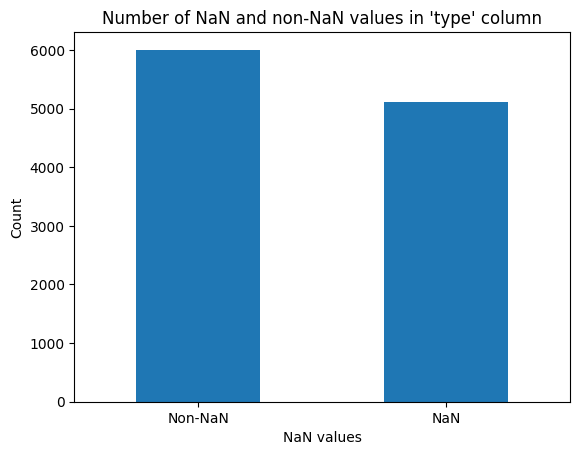

In [11]:
# Plot how many na and non-nan values in col type
iea['type'].isna().value_counts().plot(kind='bar')
plt.title("Number of NaN and non-NaN values in 'type' column")
plt.xlabel("NaN values")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-NaN', 'NaN'], rotation=0)
plt.show()

In [12]:
# CPSI Scoring & Index Calculation

#IEA Raw Policies CSV
iea["status"] = iea["status"].str.lower()
iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()

# Filter for relevant years
# iea = iea[(iea["year"] >= 2000) & (iea["year"] <= 2022)].copy()

# Get max year
max_year = iea["year"].max()
print(f"Max year in IEA data: {max_year}")

# Expand 'in force' policies for every year until 2022 (If it finds a policy in force, it will add it for every year until 2022)
expanded_rows = []
for _, row in iea.iterrows():
    if row["status"] == "in force":
        for year in range(int(row["year"]), max_year + 1):
            new_row = row.copy()
            new_row["year"] = year
            expanded_rows.append(new_row)
    elif row["status"] == "ended": # if the policy is ended, it will only be added for the year it was created
        expanded_rows.append(row)

iea = pd.DataFrame(expanded_rows)
iea = iea.sort_values(by="year").reset_index(drop=True)

### ! Alternate IEA dataframe without expanding policies for subsequent years + without ended

#iea = pd.read_csv("/Users/cynthiasalinas/Documents/econ_climate/important/IEA_policies_raw.csv", encoding="ISO-8859-1")
#iea = iea[iea["status"].str.lower() == "in force"]
#iea = iea[(iea["year"] >= 2000) & (iea["year"] <= 2022)].copy()
#iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()

#Type & Category Mappings
type_mapping = pd.read_csv("Type_C-Level_Mapping.csv")
category_mapping = pd.read_csv("Category_Theme_Mapping.csv")
topic_mapping = pd.read_csv("Topic_Theme_Mapping.csv")

# Dictionaries for mappings
type_dict = dict(zip(type_mapping['type'], type_mapping['C_level']))
topic_dict = dict(zip(topic_mapping['topic'], topic_mapping['topic_theme_14_refined']))
category_dict = dict(zip(category_mapping['category'], category_mapping['category_theme_27']))

count_policies = len(iea)
print(f"Number of policies: {count_policies}")

Max year in IEA data: 2028
Number of policies: 151748


In [13]:
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category,full_text
0,1948,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
1,1949,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
2,1950,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
3,1951,National,Electricity tax,"Introduced in 1951, an electricity tax has bee...",in force,NOR,Norway,NaN,NaN,NaN,"electricity tax introduced in 1951, an electri..."
4,1951,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...


In [14]:
# Define NLP keywords for C1-C4 categories

keywords = {
    'C1': ['ban', 'banned', 'banning', 'prohibit', 'prohibition', 'restriction', 'restricted', 'mandate', 'mandatory', 'outlawed', 'phase-out', 'elimination', 'forbidden', 'sales ban', 'exploration ban'],
    'C2': ['tax', 'levy', 'pricing', 'carbon pricing', 'fuel tax', 'tariff', 'subsidy removal'],
    'C3': ['standard', 'performance', 'emissions limit', 'efficiency code', 'compliance', 'emissions cap', 'minimum standard', 'permitting'],
    'C4': ['grant', 'funding', 'finance', 'subsidy', 'support', 'r&d', 'research', 'development', 'information', 'education', 'training', 'capacity-building', 'knowledge', 'awareness', 'incentives', 'investment', 'pilot program', 'dialogue', 'workshops', 'partnership']
}

# NLP-based scoring function
def nlp_score(row):
    text = ' '.join([str(row['topic']), str(row['description'])]).lower()
    for level, words in keywords.items():
        if any(word in text for word in words):
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return 0.25

# Assign C-level scores based on type
def type_score(row):
    if pd.notna(row['type']):
        mapping = type_mapping[type_mapping['type'] == row['type']]
        if not mapping.empty:
            level = mapping.iloc[0]['C_level']
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return None

# Apply scoring logic clearly
# iea['score_type'] = iea.apply(type_score, axis=1)
iea['score_nlp'] = iea.apply(nlp_score, axis=1)
# iea['final_score'] = iea[['score_type', 'score_nlp']].max(axis=1) # Final score is the maximum of type and NLP scores

# Direct assignment
iea['topic_theme_14_refined'] = iea['topic'].map(topic_dict).fillna('Other')
iea['category_theme_27'] = iea['category'].map(category_dict).fillna('Other')

# Scored policies dataframe
iea_scored_policies = iea[['country', 'iso_alpha_3', 'year', 'jurisdiction', 'type', 'topic', 'category',
                           'score_nlp', 'topic_theme_14_refined', 'category_theme_27']]
iea_scored_policies.head()

,country,iso_alpha_3,year,jurisdiction,type,topic,category,score_nlp,topic_theme_14_refined,category_theme_27
0,India,IND,1948,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
1,India,IND,1949,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
2,India,IND,1950,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
3,Norway,NOR,1951,National,NaN,NaN,NaN,0.75,Cross-cutting / Economy-wide,Other
4,India,IND,1951,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other


In [15]:
# scoring_test_df = iea[iea.score_type.notna()][['score_type', 'score_nlp']].copy()
# scoring_test_df.reset_index(drop=True, inplace=True)

# scoring_test_df

In [16]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# mae = mean_absolute_error(scoring_test_df['score_type'], scoring_test_df['score_nlp'])
# mse = mean_squared_error(scoring_test_df['score_type'], scoring_test_df['score_nlp'])
# r2 = r2_score(scoring_test_df['score_type'], scoring_test_df['score_nlp'])

# print(f"MAE: {mae}")
# print(f"MSE: {mse}")
# print(f"R²: {r2}")

In [17]:
# plt.scatter(scoring_test_df['score_type'], scoring_test_df['score_nlp'], alpha=0.5)
# plt.plot([0, 1], [0, 1], '--') # Diagonal line for reference
# plt.xlabel('Ground Truth (score_type)')
# plt.ylabel('Approximation (score_nlp)')
# plt.title('Ground Truth vs NLP Approximation')
# plt.show()

In [18]:
# rename score_nlp col to final_score
iea_scored_policies = iea_scored_policies.rename(columns={'score_nlp': 'final_score'})

In [19]:
import numpy as np

iea_scored_cpsi = iea_scored_policies.groupby(['iso_alpha_3', 'year']).agg(
    avg_score=('final_score', 'mean'),
    policy_count=('final_score', 'count'),
    dominant_topic=('topic_theme_14_refined', lambda x: x.mode()[0] if not x.isna().all() else np.nan),
    dominant_category=('category_theme_27', lambda x: x.mode()[0] if not x.isna().all() else np.nan)
).reset_index()

# Composite index: average score * log(1 + policy count)
iea_scored_cpsi['CPSI'] = iea_scored_cpsi['avg_score'] * np.log1p(iea_scored_cpsi['policy_count'])


iea_scored_cpsi.head()


,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI
0,AFG,1971,0.75,1,Energy,Solar Power,0.51986
1,AFG,1972,0.75,1,Energy,Solar Power,0.51986
2,AFG,1973,0.75,1,Energy,Solar Power,0.51986
3,AFG,1974,0.75,1,Energy,Solar Power,0.51986
4,AFG,1975,0.75,1,Energy,Solar Power,0.51986


In [20]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'CHE'].tail()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI
1417,CHE,2024,0.636842,95,Cross-cutting / Economy-wide,Other,2.906769
1418,CHE,2025,0.636842,95,Cross-cutting / Economy-wide,Other,2.906769
1419,CHE,2026,0.636842,95,Cross-cutting / Economy-wide,Other,2.906769
1420,CHE,2027,0.636842,95,Cross-cutting / Economy-wide,Other,2.906769
1421,CHE,2028,0.636842,95,Cross-cutting / Economy-wide,Other,2.906769


In [21]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'USA'].tail()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI
8772,USA,2024,0.483670,643,Cross-cutting / Economy-wide,Other,3.128234
8773,USA,2025,0.483670,643,Cross-cutting / Economy-wide,Other,3.128234
8774,USA,2026,0.483670,643,Cross-cutting / Economy-wide,Other,3.128234
8775,USA,2027,0.483721,645,Cross-cutting / Economy-wide,Other,3.130061
8776,USA,2028,0.483721,645,Cross-cutting / Economy-wide,Other,3.130061


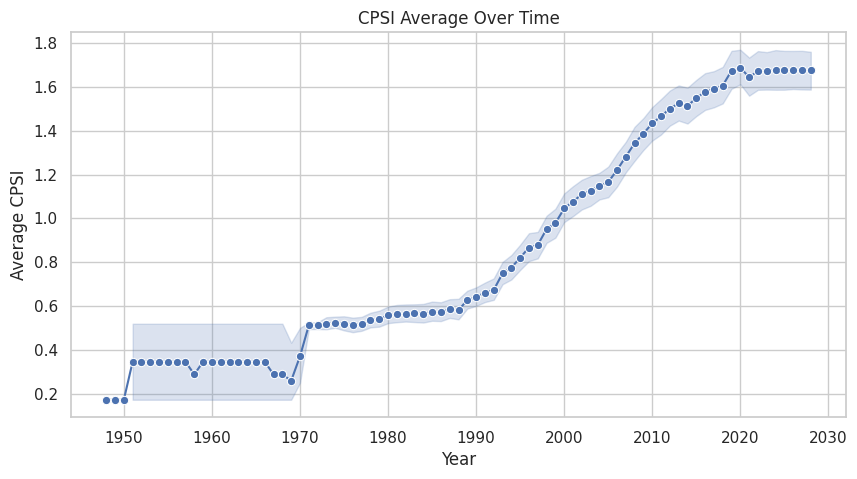

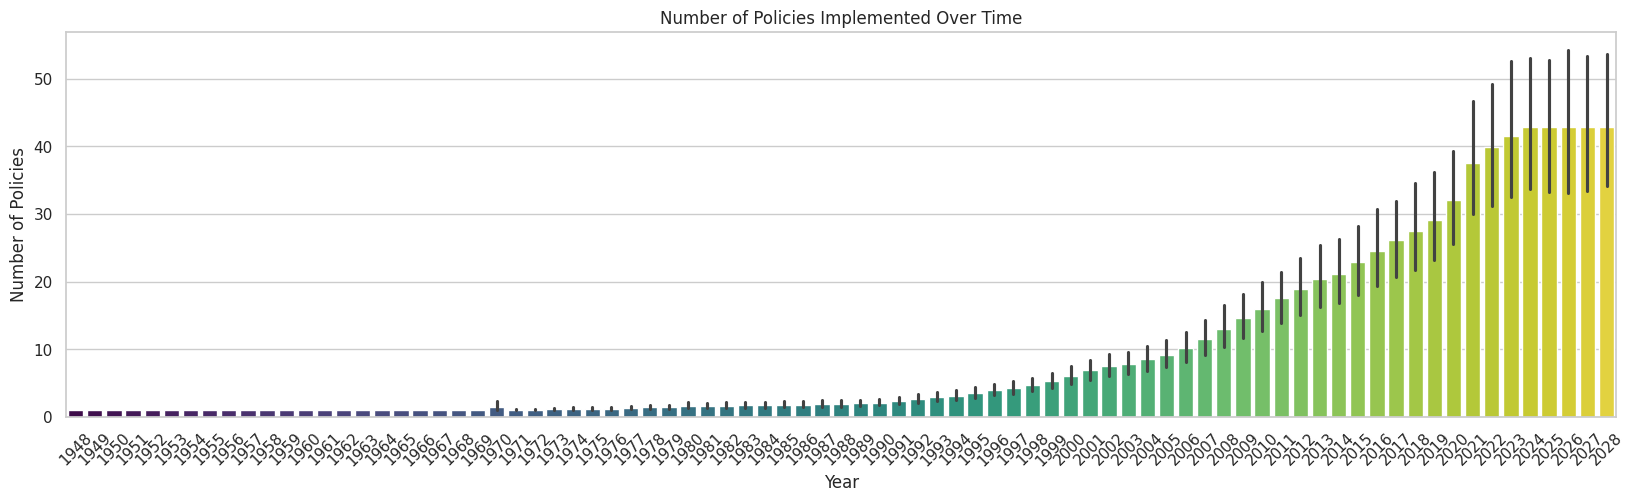

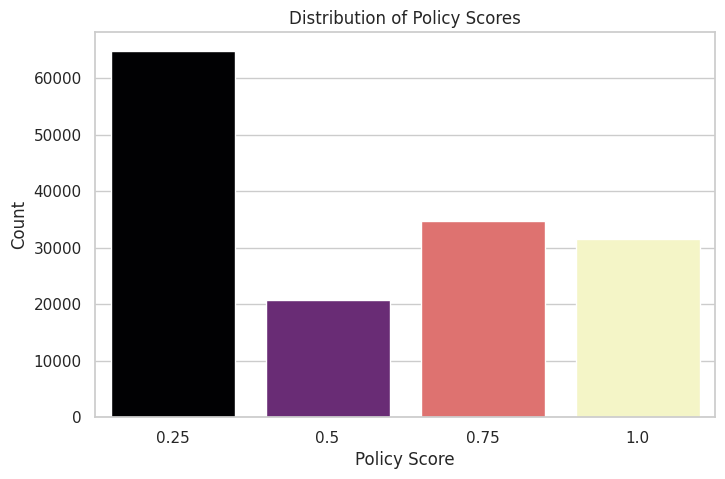

<Figure size 1200x600 with 0 Axes>

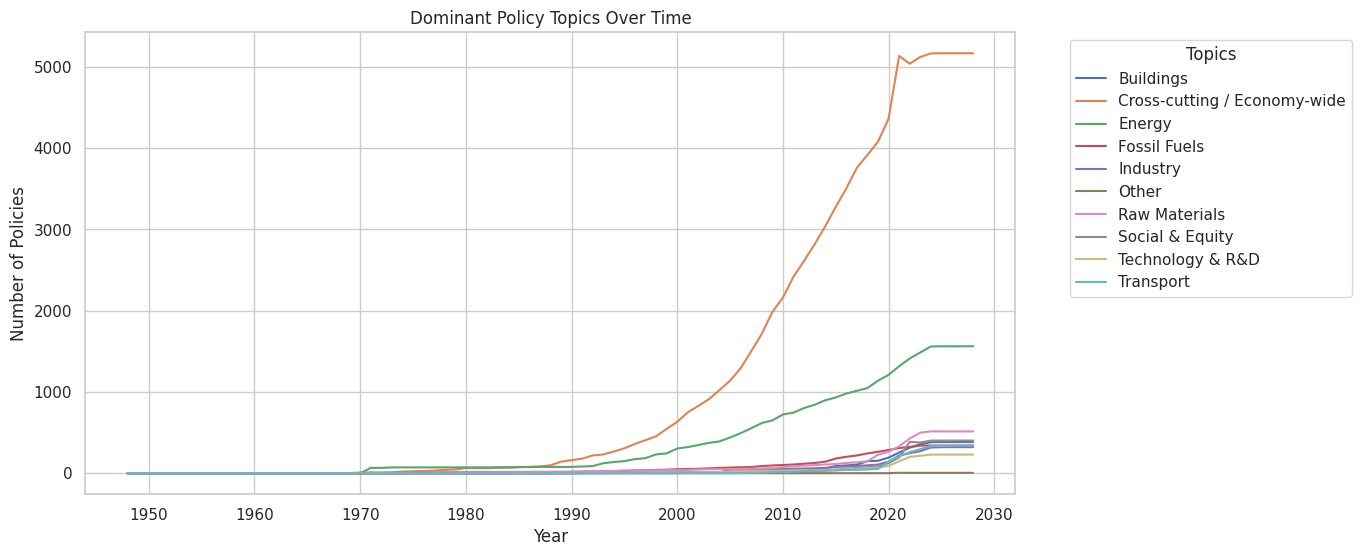

<Figure size 1200x600 with 0 Axes>

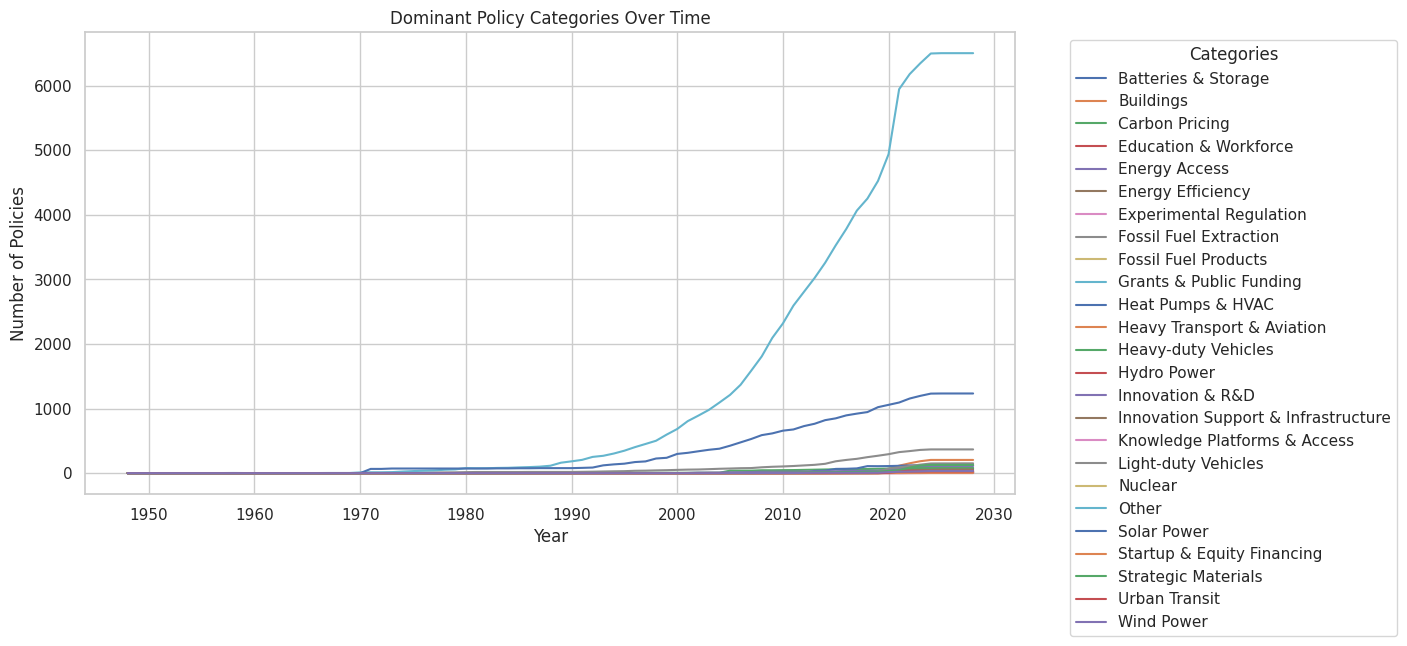

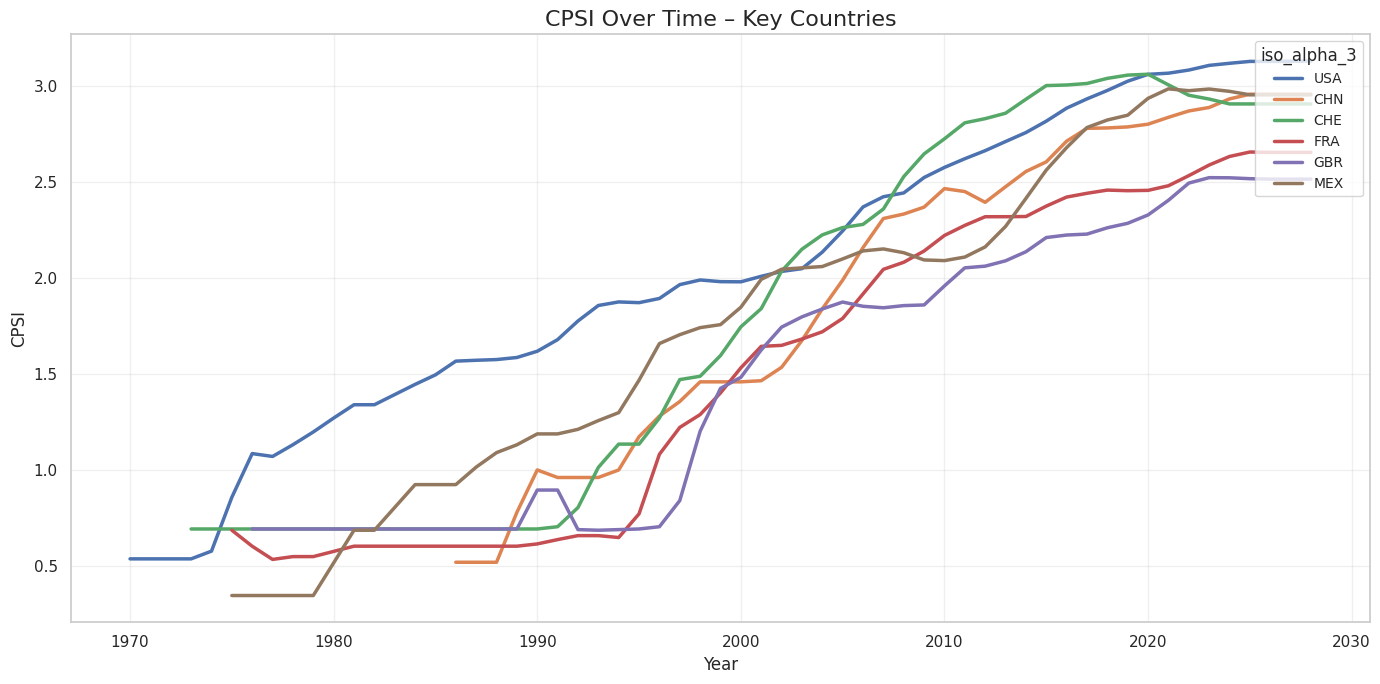

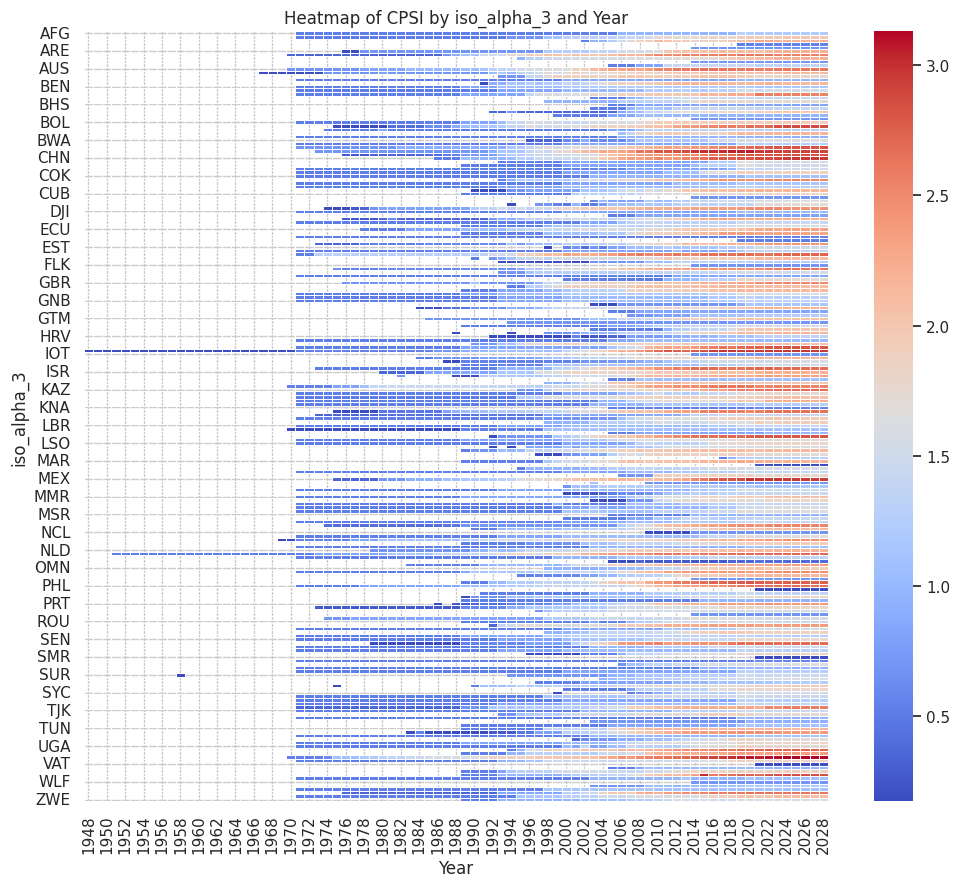

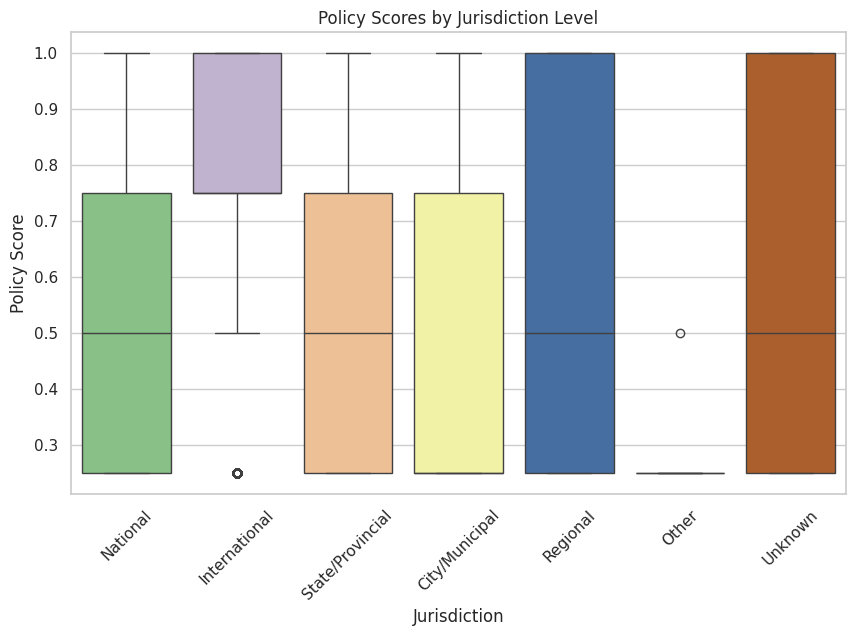

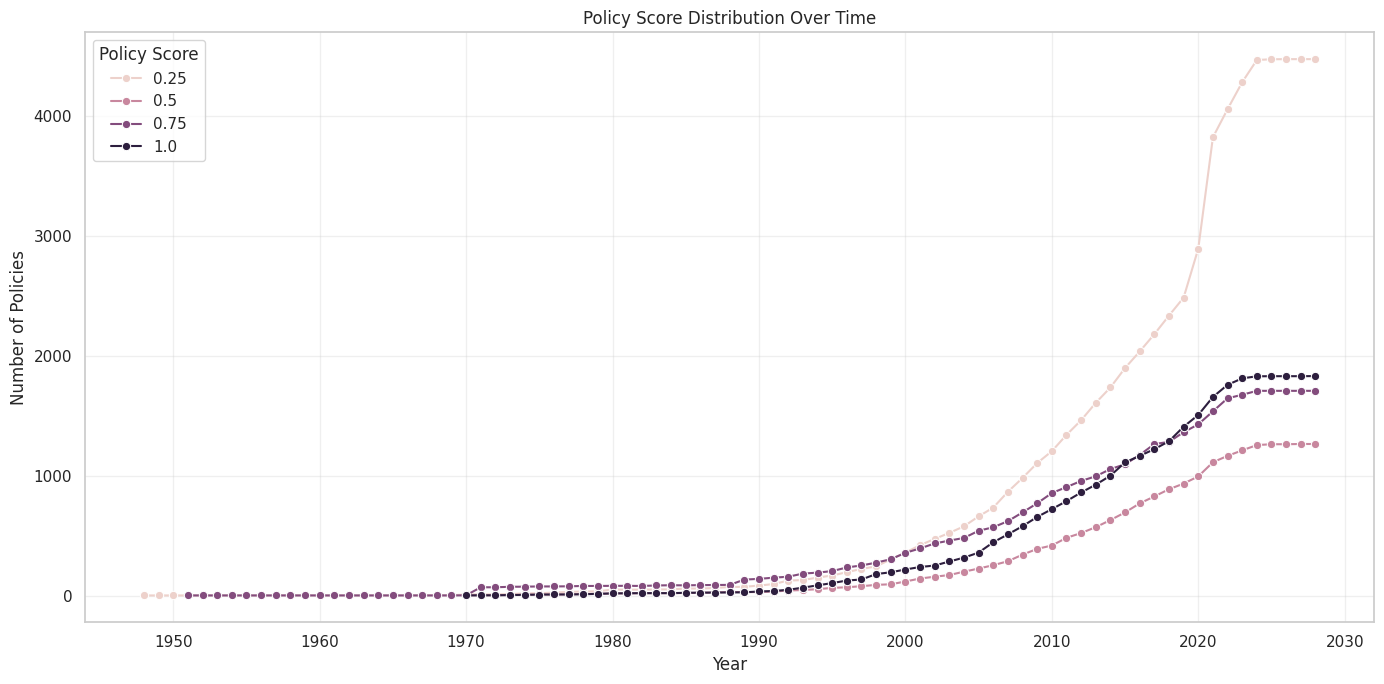

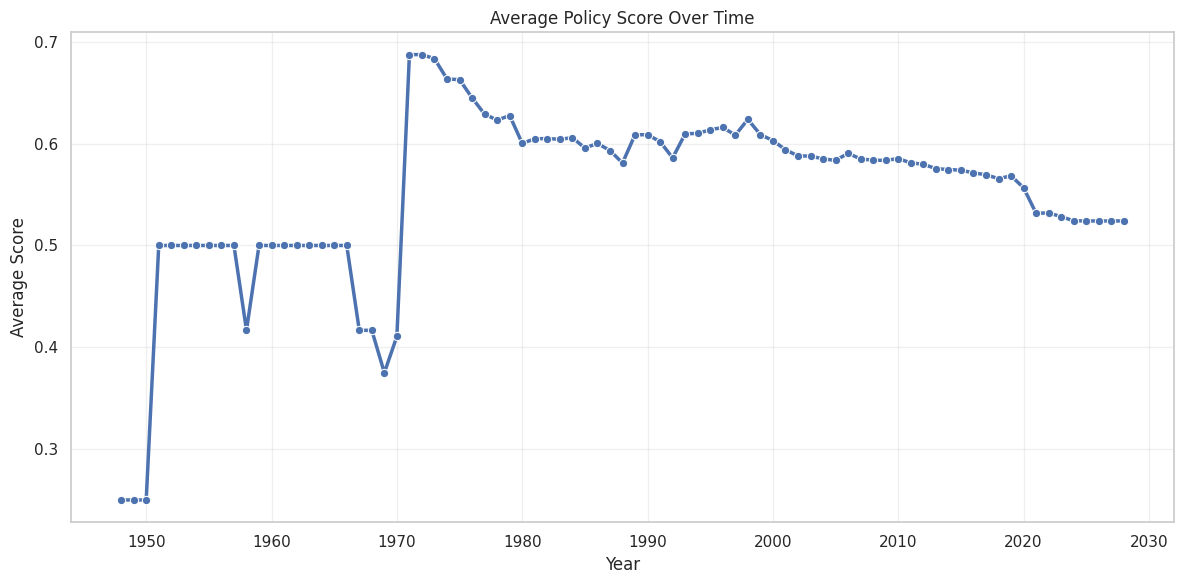

Top 5 Countries by Policy Count:
   iso_alpha_3  Policy Count
0         USA         10816
1         CAN          5062
2         AUS          4819
3         DEU          4352
4         EUR          4068
Summary Statistics of CPSI:
 count    9255.000000
mean        1.178374
std         0.660968
min         0.173287
25%         0.519860
50%         1.039721
75%         1.621592
max         3.130061
Name: CPSI, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Graph 1: CPSI Average Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(data=iea_scored_cpsi, x='year', y='CPSI', marker='o')
plt.title('CPSI Average Over Time')
plt.ylabel('Average CPSI')
plt.xlabel('Year')
plt.show()

# Graph 2: Policy Count Over Time
plt.figure(figsize=(20, 5))
sns.barplot(data=iea_scored_cpsi, x='year', y='policy_count', hue='year', palette='viridis', legend=False)
plt.title('Number of Policies Implemented Over Time')
plt.ylabel('Number of Policies')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

# Graph 3: Policy Score Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=iea_scored_policies, x='final_score', hue='final_score', palette='magma', legend=False)
plt.title('Distribution of Policy Scores')
plt.ylabel('Count')
plt.xlabel('Policy Score')
plt.show()

# Graph 4: Dominant Topics Over Time
plt.figure(figsize=(12, 6))
topic_trends = iea_scored_policies.groupby(['year', 'topic_theme_14_refined']).size().unstack().fillna(0)
topic_trends.plot(kind='line', figsize=(12, 6))
plt.title('Dominant Policy Topics Over Time')
plt.ylabel('Number of Policies')
plt.xlabel('Year')
plt.legend(title='Topics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Graph 5: Dominant Categories Over Time
plt.figure(figsize=(12, 6))
category_trends = iea_scored_policies.groupby(['year', 'category_theme_27']).size().unstack().fillna(0)
category_trends.plot(kind='line', figsize=(12, 6))
plt.title('Dominant Policy Categories Over Time')
plt.ylabel('Number of Policies')
plt.xlabel('Year')
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Graph 6: # CPSI Over Time – Key Economies
important_countries = ['USA', 'CHN', 'CHE', 'FRA', 'GBR', 'MEX']
important_trend = iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'].isin(important_countries)]
plt.figure(figsize=(14, 7))
for iso_alpha_3 in important_countries:
    country_data = important_trend[important_trend['iso_alpha_3'] == iso_alpha_3].sort_values('year')
    smoothed = country_data.set_index('year')['CPSI'].rolling(window=2, min_periods=1).mean()
    plt.plot(smoothed.index, smoothed.values, label=iso_alpha_3, linewidth=2.5)
plt.title('CPSI Over Time – Key Countries', fontsize=16)
plt.ylabel('CPSI', fontsize=12)
plt.xlabel('Year', fontsize=12)
# plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(title='iso_alpha_3', loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# Graph 7: Heatmap of CPSI by iso_alpha_3 and Year
heatmap_data = iea_scored_cpsi.pivot(index='iso_alpha_3', columns='year', values='CPSI')
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of CPSI by iso_alpha_3 and Year')
plt.ylabel('iso_alpha_3')
plt.xlabel('Year')
plt.show()

# Graph 8: Policy Scores by Jurisdiction
plt.figure(figsize=(10, 6))
sns.boxplot(data=iea_scored_policies, x='jurisdiction', y='final_score', hue='jurisdiction', palette='Accent', legend=False)
plt.title('Policy Scores by Jurisdiction Level')
plt.ylabel('Policy Score')
plt.xlabel('Jurisdiction')
plt.xticks(rotation=45)
plt.show()

# Graph 9: Policy Score Distribution Over Time
plt.figure(figsize=(14, 7))
score_trend = iea_scored_policies.groupby(['year', 'final_score']).size().reset_index(name='count')
sns.lineplot(data=score_trend, x='year', y='count', hue='final_score', marker='o')
plt.title('Policy Score Distribution Over Time')
plt.ylabel('Number of Policies')
plt.xlabel('Year')
plt.legend(title='Policy Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Graph 10: Average policy score over time
plt.figure(figsize=(12, 6))
avg_score_trend = (
    iea_scored_policies
    .groupby('year')['final_score']
    .mean()
    .reset_index()
)
sns.lineplot(data=avg_score_trend, x='year', y='final_score', marker='o', linewidth=2.5)
plt.title('Average Policy Score Over Time')
plt.ylabel('Average Score')
plt.xlabel('Year')
# plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Table 9: Top 5 Countries with Most Policies
policy_counts = iea_scored_policies['iso_alpha_3'].value_counts().head(5).reset_index()
policy_counts.columns = ['iso_alpha_3', 'Policy Count']
print("Top 5 Countries by Policy Count:\n", policy_counts)

# Table 10: Summary statistics of CPSI
print("Summary Statistics of CPSI:\n", iea_scored_cpsi['CPSI'].describe())

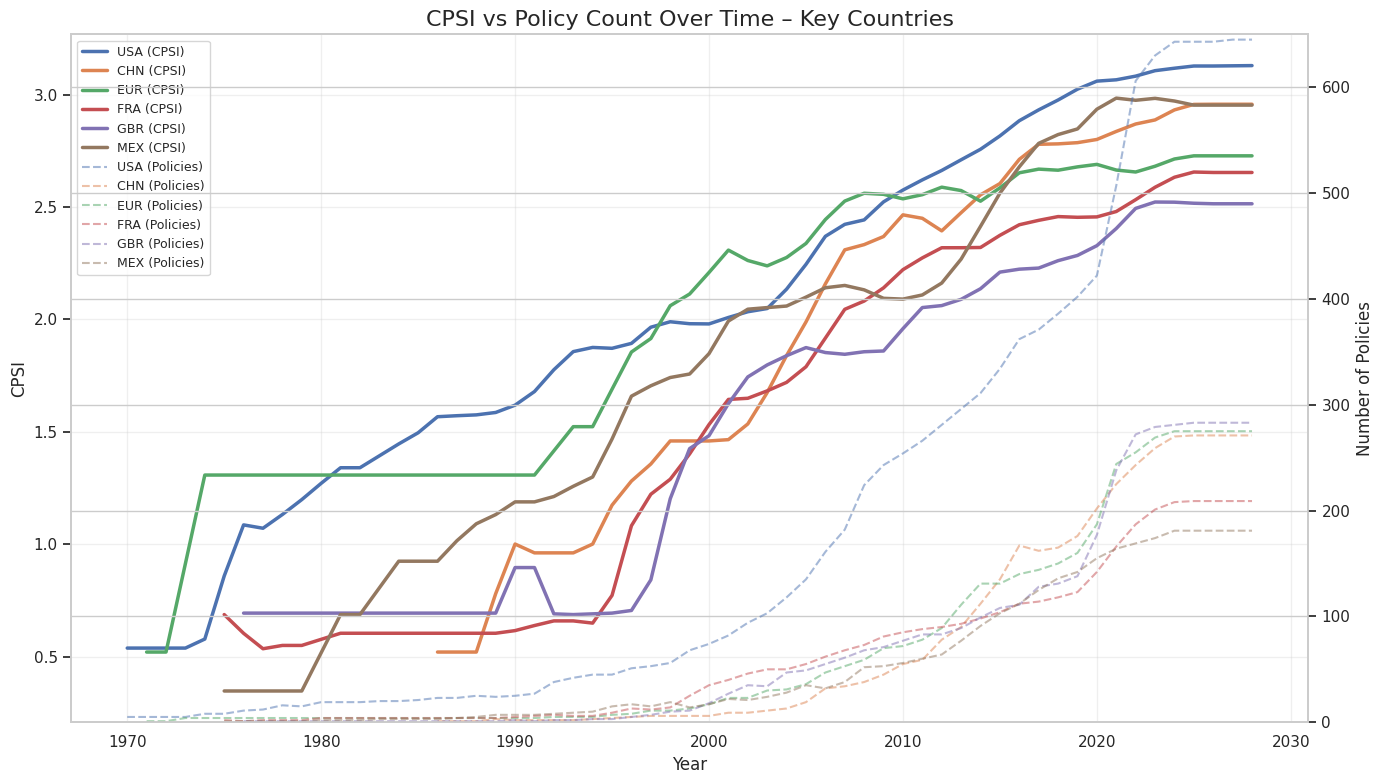

In [23]:
# Filter data for the key countries
important_countries = ['USA', 'CHN', 'EUR', 'FRA', 'GBR', 'MEX']
important_trend = iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'].isin(important_countries)]

# Plotting
plt.figure(figsize=(14, 8))

# Set up main axis
ax1 = plt.gca()

# Plot CPSI trend
for iso_alpha_3 in important_countries:
    data = important_trend[important_trend['iso_alpha_3'] == iso_alpha_3].sort_values('year')
    cpsi_smoothed = data.set_index('year')['CPSI'].rolling(window=2, min_periods=1).mean()
    ax1.plot(cpsi_smoothed.index, cpsi_smoothed.values, label=f'{iso_alpha_3} (CPSI)', linewidth=2.5)

ax1.set_ylabel('CPSI', fontsize=12)
# ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Year')
ax1.set_title('CPSI vs Policy Count Over Time – Key Countries', fontsize=16)
ax1.grid(alpha=0.3)

# Secondary Y-axis for policy count
ax2 = ax1.twinx()
for iso_alpha_3 in important_countries:
    data = important_trend[important_trend['iso_alpha_3'] == iso_alpha_3].sort_values('year')
    ax2.plot(data['year'], data['policy_count'], linestyle='--', alpha=0.5, label=f'{iso_alpha_3} (Policies)')

ax2.set_ylabel('Number of Policies', fontsize=12)
ax2.set_ylim(0, important_trend['policy_count'].max() + 5)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Save final datasets
iea_scored_policies.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_policies.csv'), index=False)
iea_scored_cpsi.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_cpsi.csv'), index=False)